In [40]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import sqlite3

import pandas as pd
import numpy as np

In [41]:
# ============================================================
# 2. PROJECT PATH AND DATABASE PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

db_path = project_root / "data" / "thesis_database.db"

print("Project root:", project_root)
print("Database path:", db_path)
print("Database exists:", db_path.exists())

Project root: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool
Database path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Database exists: True


In [42]:
# ============================================================
# 3. CONNECT TO SQLITE DATABASE
# ============================================================

conn = sqlite3.connect(db_path)

print("Connected to database")

Connected to database


In [43]:
# ============================================================
# 4. CHECK AVAILABLE TABLES
# ============================================================

tables = pd.read_sql_query(
    """
    SELECT name 
    FROM sqlite_master 
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

tables

,name
0,BiddingZones
1,Capacities
2,Flows
3,Prices
4,Regions
5,Volumes
6,sqlite_sequence


In [44]:
# ============================================================
# 5. CHECK TABLE COLUMNS
# ============================================================

table_names = ["BiddingZones", "Prices", "Volumes", "Flows", "Capacities"]

for table in table_names:
    print(f"\n--- {table} ---")
    columns = pd.read_sql_query(f"PRAGMA table_info({table});", conn)
    display(columns)


--- BiddingZones ---


,cid,name,type,notnull,dflt_value,pk
0,0,zone_id,INTEGER,0,None,1
1,1,zone_code,TEXT,1,None,0
2,2,country,TEXT,1,None,0
3,3,region_id,INTEGER,1,None,0



--- Prices ---


,cid,name,type,notnull,dflt_value,pk
0,0,price_id,INTEGER,0,None,1
1,1,zone_id,INTEGER,1,None,0
2,2,delivery_day,DATE,1,None,0
3,3,hour,INTEGER,1,None,0
4,4,price_value,REAL,1,None,0



--- Volumes ---


,cid,name,type,notnull,dflt_value,pk
0,0,volume_id,INTEGER,0,None,1
1,1,zone_id,INTEGER,1,None,0
2,2,delivery_day,DATE,1,None,0
3,3,hour,INTEGER,1,None,0
4,4,buy_volume_value,REAL,0,None,0
5,5,sell_volume_value,REAL,0,None,0



--- Flows ---


,cid,name,type,notnull,dflt_value,pk
0,0,flow_id,INTEGER,0,None,1
1,1,from_zone_id,INTEGER,1,None,0
2,2,to_zone_id,INTEGER,1,None,0
3,3,delivery_day,DATE,1,None,0
4,4,hour,INTEGER,1,None,0
5,5,flow_value,REAL,1,None,0



--- Capacities ---


,cid,name,type,notnull,dflt_value,pk
0,0,capacity_id,INTEGER,0,None,1
1,1,capacity_code,TEXT,0,None,0
2,2,from_zone_id,INTEGER,1,None,0
3,3,to_zone_id,INTEGER,1,None,0
4,4,delivery_day,DATE,1,None,0
5,5,hour,INTEGER,1,None,0
6,6,capacity_value,REAL,1,None,0


In [45]:
# ============================================================
# 6. QUICK DATA PREVIEW
# ============================================================

for table in table_names:
    print(f"\n--- {table} ---")
    df_preview = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn)
    display(df_preview)


--- BiddingZones ---


,zone_id,zone_code,country,region_id
0,1,EE,Estonia,1
1,2,LT,Lithuania,1
2,3,LV,Latvia,1
3,4,AT,Austria,2
4,5,BE,Belgium,2



--- Prices ---


,price_id,zone_id,delivery_day,hour,price_value
0,1,1,2020-01-01,0,28.78
1,2,2,2020-01-01,0,28.78
2,3,3,2020-01-01,0,28.78
3,4,4,2020-01-01,0,41.88
4,5,5,2020-01-01,0,41.88



--- Volumes ---


,volume_id,zone_id,delivery_day,hour,buy_volume_value,sell_volume_value
0,1,1,2020-01-01,0,688.8,283.8
1,2,2,2020-01-01,0,1005.3,1703.4
2,3,3,2020-01-01,0,689.7,220.3
3,4,4,2020-01-01,0,452.0,22.6
4,5,5,2020-01-01,0,119.5,130.5



--- Flows ---


,flow_id,from_zone_id,to_zone_id,delivery_day,hour,flow_value
0,1,8,13,2020-01-01,0,0.0
1,2,9,13,2020-01-01,0,0.0
2,3,11,15,2020-01-01,0,0.0
3,4,12,13,2020-01-01,0,0.0
4,5,12,14,2020-01-01,0,200.0



--- Capacities ---


,capacity_id,capacity_code,from_zone_id,to_zone_id,delivery_day,hour,capacity_value
0,1,NO1->NO3,12,14,2020-01-01,0,200.0
1,2,NO1->SE3,12,19,2020-01-01,0,1375.0
2,3,NO3->NO1,14,12,2020-01-01,0,-200.0
3,4,SE3->NO1,19,12,2020-01-01,0,1123.0
4,5,NO1->NO3,12,14,2020-01-01,1,200.0


In [46]:
# ============================================================
# 7. CHECK BIDDING ZONES
# ============================================================

zones_df = pd.read_sql_query(
    """
    SELECT *
    FROM BiddingZones
    ORDER BY zone_id;
    """,
    conn
)

zones_df

,zone_id,zone_code,country,region_id
0,1,EE,Estonia,1
1,2,LT,Lithuania,1
2,3,LV,Latvia,1
3,4,AT,Austria,2
4,5,BE,Belgium,2
5,6,FR,France,2
6,7,GER,Germany,2
7,8,NL,Netherlands,2
8,9,DK1,Denmark,3
9,10,DK2,Denmark,3


In [47]:
# ============================================================
# 8. SELECT INITIAL GNN ZONES
# ============================================================

selected_zone_codes = ["NO1", "NO2", "NO3", "NO4", "NO5"]

selected_zones = zones_df[zones_df["zone_code"].isin(selected_zone_codes)].copy()

selected_zones

,zone_id,zone_code,country,region_id
11,12,NO1,Norway,3
12,13,NO2,Norway,3
13,14,NO3,Norway,3
14,15,NO4,Norway,3
15,16,NO5,Norway,3


In [48]:
# ============================================================
# 9. CREATE NODE MAPPING
# ============================================================

selected_zones = selected_zones.sort_values("zone_code").reset_index(drop=True)

zone_id_to_node_idx = {
    zone_id: idx
    for idx, zone_id in enumerate(selected_zones["zone_id"].values)
}

node_idx_to_zone_id = {
    idx: zone_id
    for zone_id, idx in zone_id_to_node_idx.items()
}

zone_code_to_node_idx = {
    row["zone_code"]: zone_id_to_node_idx[row["zone_id"]]
    for _, row in selected_zones.iterrows()
}

print("Selected zones:")
display(selected_zones)

print("zone_id_to_node_idx:")
print(zone_id_to_node_idx)

print("zone_code_to_node_idx:")
print(zone_code_to_node_idx)

Selected zones:


,zone_id,zone_code,country,region_id
0,12,NO1,Norway,3
1,13,NO2,Norway,3
2,14,NO3,Norway,3
3,15,NO4,Norway,3
4,16,NO5,Norway,3


zone_id_to_node_idx:
{np.int64(12): 0, np.int64(13): 1, np.int64(14): 2, np.int64(15): 3, np.int64(16): 4}
zone_code_to_node_idx:
{'NO1': 0, 'NO2': 1, 'NO3': 2, 'NO4': 3, 'NO5': 4}


In [49]:
# ============================================================
# 10. LOAD FLOWS BETWEEN SELECTED ZONES
# ============================================================

selected_zone_ids = selected_zones["zone_id"].tolist()

zone_ids_sql = ",".join(str(z) for z in selected_zone_ids)

flows_no = pd.read_sql_query(
    f"""
    SELECT *
    FROM Flows
    WHERE from_zone_id IN ({zone_ids_sql})
      AND to_zone_id IN ({zone_ids_sql})
    ORDER BY delivery_day, hour, from_zone_id, to_zone_id;
    """,
    conn
)

print("Number of flow rows:", len(flows_no))
display(flows_no.head(20))

Number of flow rows: 105396


,flow_id,from_zone_id,to_zone_id,delivery_day,hour,flow_value
0,4,12,13,2020-01-01,0,0.0
1,5,12,14,2020-01-01,0,200.0
2,6,12,16,2020-01-01,0,0.0
3,10,13,12,2020-01-01,0,0.0
4,11,13,16,2020-01-01,0,0.0
5,12,14,12,2020-01-01,0,0.0
6,13,14,15,2020-01-01,0,0.0
7,14,14,16,2020-01-01,0,0.0
8,17,15,14,2020-01-01,0,357.3
9,20,16,12,2020-01-01,0,1451.7


In [50]:
# ============================================================
# 11. UNIQUE EDGES BETWEEN SELECTED ZONES
# ============================================================

unique_edges = (
    flows_no[["from_zone_id", "to_zone_id"]]
    .drop_duplicates()
    .sort_values(["from_zone_id", "to_zone_id"])
    .reset_index(drop=True)
)

display(unique_edges)

print("Number of unique directed edges:", len(unique_edges))

,from_zone_id,to_zone_id
0,12,13
1,12,14
2,12,16
3,13,12
4,13,16
5,14,12
6,14,15
7,14,16
8,15,14
9,16,12


Number of unique directed edges: 12


In [51]:
# ============================================================
# 12. UNIQUE EDGES WITH ZONE CODES
# ============================================================

zone_id_to_code = dict(zip(zones_df["zone_id"], zones_df["zone_code"]))

unique_edges_named = unique_edges.copy()
unique_edges_named["from_zone_code"] = unique_edges_named["from_zone_id"].map(zone_id_to_code)
unique_edges_named["to_zone_code"] = unique_edges_named["to_zone_id"].map(zone_id_to_code)

unique_edges_named = unique_edges_named[
    ["from_zone_id", "from_zone_code", "to_zone_id", "to_zone_code"]
]

display(unique_edges_named)

,from_zone_id,from_zone_code,to_zone_id,to_zone_code
0,12,NO1,13,NO2
1,12,NO1,14,NO3
2,12,NO1,16,NO5
3,13,NO2,12,NO1
4,13,NO2,16,NO5
5,14,NO3,12,NO1
6,14,NO3,15,NO4
7,14,NO3,16,NO5
8,15,NO4,14,NO3
9,16,NO5,12,NO1


In [52]:
# ============================================================
# 13. BUILD EDGE INDEX
# ============================================================

edge_index_list = []

for _, row in unique_edges.iterrows():
    from_node_idx = zone_id_to_node_idx[row["from_zone_id"]]
    to_node_idx = zone_id_to_node_idx[row["to_zone_id"]]
    edge_index_list.append([from_node_idx, to_node_idx])

edge_index = np.array(edge_index_list).T

print("edge_index:")
print(edge_index)

print("edge_index shape:", edge_index.shape)

edge_index:
[[0 0 0 1 1 2 2 2 3 4 4 4]
 [1 2 4 0 4 0 3 4 2 0 1 2]]
edge_index shape: (2, 12)


In [53]:
# ============================================================
# 14. LOAD NODE DATA FOR SELECTED ZONES
# ============================================================

node_df = pd.read_sql_query(
    f"""
    SELECT
        p.zone_id,
        p.delivery_day,
        p.hour,
        p.price_value,
        v.buy_volume_value,
        v.sell_volume_value
    FROM Prices p
    LEFT JOIN Volumes v
        ON p.zone_id = v.zone_id
       AND p.delivery_day = v.delivery_day
       AND p.hour = v.hour
    WHERE p.zone_id IN ({zone_ids_sql})
    ORDER BY p.delivery_day, p.hour, p.zone_id;
    """,
    conn
)

node_df["datetime"] = pd.to_datetime(node_df["delivery_day"]) + pd.to_timedelta(node_df["hour"], unit="h")

print("Node rows:", len(node_df))
display(node_df.head(15))
display(node_df.tail(15))

Node rows: 252015


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
0,12,2020-01-01,0,31.82,4176.9,1802.2,2020-01-01 00:00:00
1,13,2020-01-01,0,31.82,3685.5,4355.2,2020-01-01 00:00:00
2,14,2020-01-01,0,28.78,2878.6,2539.4,2020-01-01 00:00:00
3,15,2020-01-01,0,28.78,1765.6,2922.9,2020-01-01 00:00:00
4,16,2020-01-01,0,31.82,2044.0,3707.0,2020-01-01 00:00:00
5,12,2020-01-01,1,31.77,4091.8,1819.6,2020-01-01 01:00:00
6,13,2020-01-01,1,31.77,3641.6,4274.7,2020-01-01 01:00:00
7,14,2020-01-01,1,28.45,2844.3,2437.2,2020-01-01 01:00:00
8,15,2020-01-01,1,28.45,1758.2,2863.9,2020-01-01 01:00:00
9,16,2020-01-01,1,31.77,2021.9,3605.3,2020-01-01 01:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
252000,12,2025-09-30,21,52.99,NaN,NaN,2025-09-30 21:00:00
252001,13,2025-09-30,21,82.87,NaN,NaN,2025-09-30 21:00:00
252002,14,2025-09-30,21,4.93,NaN,NaN,2025-09-30 21:00:00
252003,15,2025-09-30,21,4.20,NaN,NaN,2025-09-30 21:00:00
252004,16,2025-09-30,21,58.54,NaN,NaN,2025-09-30 21:00:00
252005,12,2025-09-30,22,47.38,NaN,NaN,2025-09-30 22:00:00
252006,13,2025-09-30,22,72.38,NaN,NaN,2025-09-30 22:00:00
252007,14,2025-09-30,22,3.80,NaN,NaN,2025-09-30 22:00:00
252008,15,2025-09-30,22,4.23,NaN,NaN,2025-09-30 22:00:00
252009,16,2025-09-30,22,58.30,NaN,NaN,2025-09-30 22:00:00


In [54]:
# ============================================================
# 15. CHECK NODE COMPLETENESS PER DATETIME
# ============================================================

nodes_per_datetime = (
    node_df.groupby("datetime")["zone_id"]
    .nunique()
    .reset_index(name="num_zones")
)

display(nodes_per_datetime["num_zones"].value_counts().sort_index())

incomplete_datetimes = nodes_per_datetime[nodes_per_datetime["num_zones"] < len(selected_zone_ids)]

print("Incomplete datetimes:", len(incomplete_datetimes))
display(incomplete_datetimes.head())

num_zones
5    50394
Name: count, dtype: int64

Incomplete datetimes: 0


,datetime,num_zones


In [55]:
# ============================================================
# 16. CREATE TARGET PRICE T+1
# ============================================================

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

node_df["target_price_t_plus_1"] = (
    node_df.groupby("zone_id")["price_value"]
    .shift(-1)
)

display(node_df.head(15))
display(node_df.tail(15))

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,target_price_t_plus_1
0,12,2020-01-01,0,31.82,4176.9,1802.2,2020-01-01 00:00:00,31.77
5,12,2020-01-01,1,31.77,4091.8,1819.6,2020-01-01 01:00:00,31.57
10,12,2020-01-01,2,31.57,4021.3,1826.2,2020-01-01 02:00:00,31.28
15,12,2020-01-01,3,31.28,3975.7,1836.8,2020-01-01 03:00:00,30.72
20,12,2020-01-01,4,30.72,3993.6,1841.5,2020-01-01 04:00:00,30.27
25,12,2020-01-01,5,30.27,4041.5,1798.0,2020-01-01 05:00:00,30.17
30,12,2020-01-01,6,30.17,4176.0,1762.8,2020-01-01 06:00:00,30.14
35,12,2020-01-01,7,30.14,4316.6,1750.4,2020-01-01 07:00:00,30.49
40,12,2020-01-01,8,30.49,4639.3,1970.5,2020-01-01 08:00:00,30.59
45,12,2020-01-01,9,30.59,4766.5,1943.4,2020-01-01 09:00:00,30.27


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,target_price_t_plus_1
251944,16,2025-09-30,9,58.68,NaN,NaN,2025-09-30 09:00:00,56.65
251949,16,2025-09-30,10,56.65,NaN,NaN,2025-09-30 10:00:00,56.20
251954,16,2025-09-30,11,56.20,NaN,NaN,2025-09-30 11:00:00,55.83
251959,16,2025-09-30,12,55.83,NaN,NaN,2025-09-30 12:00:00,56.16
251964,16,2025-09-30,13,56.16,NaN,NaN,2025-09-30 13:00:00,55.75
251969,16,2025-09-30,14,55.75,NaN,NaN,2025-09-30 14:00:00,55.66
251974,16,2025-09-30,15,55.66,NaN,NaN,2025-09-30 15:00:00,57.13
251979,16,2025-09-30,16,57.13,NaN,NaN,2025-09-30 16:00:00,58.53
251984,16,2025-09-30,17,58.53,NaN,NaN,2025-09-30 17:00:00,59.74
251989,16,2025-09-30,18,59.74,NaN,NaN,2025-09-30 18:00:00,62.35


In [56]:
# ============================================================
# 17. BUILD X AND Y FOR ONE DATETIME
# ============================================================

example_datetime = node_df["datetime"].min()

node_snapshot = (
    node_df[node_df["datetime"] == example_datetime]
    .copy()
    .sort_values("zone_id")
)

display(node_snapshot)

node_feature_columns = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
]

x = node_snapshot[node_feature_columns].to_numpy(dtype=np.float32)
y = node_snapshot["target_price_t_plus_1"].to_numpy(dtype=np.float32)

print("Example datetime:", example_datetime)
print("x shape:", x.shape)
print("y shape:", y.shape)

print("x:")
print(x)

print("y:")
print(y)

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,target_price_t_plus_1
0,12,2020-01-01,0,31.82,4176.9,1802.2,2020-01-01,31.77
1,13,2020-01-01,0,31.82,3685.5,4355.2,2020-01-01,31.77
2,14,2020-01-01,0,28.78,2878.6,2539.4,2020-01-01,28.45
3,15,2020-01-01,0,28.78,1765.6,2922.9,2020-01-01,28.45
4,16,2020-01-01,0,31.82,2044.0,3707.0,2020-01-01,31.77


Example datetime: 2020-01-01 00:00:00
x shape: (5, 3)
y shape: (5,)
x:
[[  31.82 4176.9  1802.2 ]
 [  31.82 3685.5  4355.2 ]
 [  28.78 2878.6  2539.4 ]
 [  28.78 1765.6  2922.9 ]
 [  31.82 2044.   3707.  ]]
y:
[31.77 31.77 28.45 28.45 31.77]


In [57]:
# ============================================================
# 18. LOAD CAPACITIES BETWEEN SELECTED ZONES
# ============================================================

capacities_no = pd.read_sql_query(
    f"""
    SELECT *
    FROM Capacities
    WHERE from_zone_id IN ({zone_ids_sql})
      AND to_zone_id IN ({zone_ids_sql})
    ORDER BY delivery_day, hour, from_zone_id, to_zone_id;
    """,
    conn
)

print("Number of capacity rows:", len(capacities_no))
display(capacities_no.head(20))

Number of capacity rows: 17566


,capacity_id,capacity_code,from_zone_id,to_zone_id,delivery_day,hour,capacity_value
0,1,NO1->NO3,12,14,2020-01-01,0,200.0
1,3,NO3->NO1,14,12,2020-01-01,0,-200.0
2,5,NO1->NO3,12,14,2020-01-01,1,200.0
3,7,NO3->NO1,14,12,2020-01-01,1,-200.0
4,9,NO1->NO3,12,14,2020-01-01,2,200.0
5,11,NO3->NO1,14,12,2020-01-01,2,-200.0
6,13,NO1->NO3,12,14,2020-01-01,3,200.0
7,15,NO3->NO1,14,12,2020-01-01,3,-200.0
8,17,NO1->NO3,12,14,2020-01-01,4,200.0
9,19,NO3->NO1,14,12,2020-01-01,4,-200.0


In [58]:
# ============================================================
# 19. CREATE DATETIME IN FLOWS AND CAPACITIES
# ============================================================

flows_no = flows_no.copy()
capacities_no = capacities_no.copy()

flows_no["datetime"] = (
    pd.to_datetime(flows_no["delivery_day"]) 
    + pd.to_timedelta(flows_no["hour"], unit="h")
)

capacities_no["datetime"] = (
    pd.to_datetime(capacities_no["delivery_day"]) 
    + pd.to_timedelta(capacities_no["hour"], unit="h")
)

display(flows_no.head())
display(capacities_no.head())

,flow_id,from_zone_id,to_zone_id,delivery_day,hour,flow_value,datetime
0,4,12,13,2020-01-01,0,0.0,2020-01-01
1,5,12,14,2020-01-01,0,200.0,2020-01-01
2,6,12,16,2020-01-01,0,0.0,2020-01-01
3,10,13,12,2020-01-01,0,0.0,2020-01-01
4,11,13,16,2020-01-01,0,0.0,2020-01-01


,capacity_id,capacity_code,from_zone_id,to_zone_id,delivery_day,hour,capacity_value,datetime
0,1,NO1->NO3,12,14,2020-01-01,0,200.0,2020-01-01 00:00:00
1,3,NO3->NO1,14,12,2020-01-01,0,-200.0,2020-01-01 00:00:00
2,5,NO1->NO3,12,14,2020-01-01,1,200.0,2020-01-01 01:00:00
3,7,NO3->NO1,14,12,2020-01-01,1,-200.0,2020-01-01 01:00:00
4,9,NO1->NO3,12,14,2020-01-01,2,200.0,2020-01-01 02:00:00


In [59]:
# ============================================================
# 20. MERGE FLOWS AND CAPACITIES
# ============================================================

edge_df = flows_no.merge(
    capacities_no[
        [
            "from_zone_id",
            "to_zone_id",
            "datetime",
            "capacity_value",
        ]
    ],
    on=["from_zone_id", "to_zone_id", "datetime"],
    how="left"
)

print("Edge rows:", len(edge_df))
display(edge_df.head(20))

print("Missing capacity values:", edge_df["capacity_value"].isna().sum())

Edge rows: 105396


,flow_id,from_zone_id,to_zone_id,delivery_day,hour,flow_value,datetime,capacity_value
0,4,12,13,2020-01-01,0,0.0,2020-01-01 00:00:00,NaN
1,5,12,14,2020-01-01,0,200.0,2020-01-01 00:00:00,200.0
2,6,12,16,2020-01-01,0,0.0,2020-01-01 00:00:00,NaN
3,10,13,12,2020-01-01,0,0.0,2020-01-01 00:00:00,NaN
4,11,13,16,2020-01-01,0,0.0,2020-01-01 00:00:00,NaN
5,12,14,12,2020-01-01,0,0.0,2020-01-01 00:00:00,-200.0
6,13,14,15,2020-01-01,0,0.0,2020-01-01 00:00:00,NaN
7,14,14,16,2020-01-01,0,0.0,2020-01-01 00:00:00,NaN
8,17,15,14,2020-01-01,0,357.3,2020-01-01 00:00:00,NaN
9,20,16,12,2020-01-01,0,1451.7,2020-01-01 00:00:00,NaN


Missing capacity values: 87830


In [60]:
# ============================================================
# 21. BUILD EDGE ATTR FOR ONE DATETIME - FLOW ONLY
# ============================================================

edge_snapshot = (
    flows_no[flows_no["datetime"] == example_datetime]
    .copy()
)

# Keep the same edge order as unique_edges / edge_index
edge_snapshot = unique_edges.merge(
    edge_snapshot,
    on=["from_zone_id", "to_zone_id"],
    how="left"
)

display(edge_snapshot[
    [
        "from_zone_id",
        "to_zone_id",
        "datetime",
        "flow_value",
    ]
])

edge_feature_columns = [
    "flow_value",
]

edge_attr = edge_snapshot[edge_feature_columns].to_numpy(dtype=np.float32)

print("Example datetime:", example_datetime)
print("edge_attr shape:", edge_attr.shape)
print("edge_attr:")
print(edge_attr)

,from_zone_id,to_zone_id,datetime,flow_value
0,12,13,2020-01-01,0.0
1,12,14,2020-01-01,200.0
2,12,16,2020-01-01,0.0
3,13,12,2020-01-01,0.0
4,13,16,2020-01-01,0.0
5,14,12,2020-01-01,0.0
6,14,15,2020-01-01,0.0
7,14,16,2020-01-01,0.0
8,15,14,2020-01-01,357.3
9,16,12,2020-01-01,1451.7


Example datetime: 2020-01-01 00:00:00
edge_attr shape: (12, 1)
edge_attr:
[[   0. ]
 [ 200. ]
 [   0. ]
 [   0. ]
 [   0. ]
 [   0. ]
 [   0. ]
 [   0. ]
 [ 357.3]
 [1451.7]
 [  61.3]
 [ 150. ]]


In [61]:
# ============================================================
# 22. CHECK MISSING VALUES IN FIRST GRAPH - FLOW ONLY
# ============================================================

print("Missing values in edge_snapshot:")
display(edge_snapshot[["flow_value"]].isna().sum())

print("Missing values in x:")
print(np.isnan(x).sum())

print("Missing values in y:")
print(np.isnan(y).sum())

print("Missing values in edge_attr:")
print(np.isnan(edge_attr).sum())

Missing values in edge_snapshot:


flow_value    0
dtype: int64

Missing values in x:
0
Missing values in y:
0
Missing values in edge_attr:
0


In [62]:
# ============================================================
# 23. CREATE FIRST GRAPH AS DICTIONARY
# ============================================================

graph = {
    "datetime": example_datetime,
    "x": x,
    "edge_index": edge_index,
    "edge_attr": edge_attr,
    "y": y,
}

print("Graph datetime:", graph["datetime"])
print("x shape:", graph["x"].shape)
print("edge_index shape:", graph["edge_index"].shape)
print("edge_attr shape:", graph["edge_attr"].shape)
print("y shape:", graph["y"].shape)

Graph datetime: 2020-01-01 00:00:00
x shape: (5, 3)
edge_index shape: (2, 12)
edge_attr shape: (12, 1)
y shape: (5,)


In [63]:
# ============================================================
# 24. CHECK NODE ORDER
# ============================================================

node_order_check = selected_zones.copy()
node_order_check["node_idx"] = node_order_check["zone_id"].map(zone_id_to_node_idx)

node_order_check = node_order_check.sort_values("node_idx")

display(node_order_check[["node_idx", "zone_id", "zone_code"]])

,node_idx,zone_id,zone_code
0,0,12,NO1
1,1,13,NO2
2,2,14,NO3
3,3,15,NO4
4,4,16,NO5


In [64]:
# ============================================================
# 25. CHECK EDGE ORDER
# ============================================================

edge_order_check = unique_edges_named.copy()
edge_order_check["from_node_idx"] = edge_order_check["from_zone_id"].map(zone_id_to_node_idx)
edge_order_check["to_node_idx"] = edge_order_check["to_zone_id"].map(zone_id_to_node_idx)

edge_order_check["flow_value"] = edge_attr[:, 0]

display(edge_order_check[
    [
        "from_node_idx",
        "to_node_idx",
        "from_zone_code",
        "to_zone_code",
        "flow_value",
    ]
])

,from_node_idx,to_node_idx,from_zone_code,to_zone_code,flow_value
0,0,1,NO1,NO2,0.000000
1,0,2,NO1,NO3,200.000000
2,0,4,NO1,NO5,0.000000
3,1,0,NO2,NO1,0.000000
4,1,4,NO2,NO5,0.000000
5,2,0,NO3,NO1,0.000000
6,2,3,NO3,NO4,0.000000
7,2,4,NO3,NO5,0.000000
8,3,2,NO4,NO3,357.299988
9,4,0,NO5,NO1,1451.699951


In [65]:
# ============================================================
# 26. FIRST GRAPH SUMMARY
# ============================================================

num_nodes = graph["x"].shape[0]
num_node_features = graph["x"].shape[1]
num_edges = graph["edge_index"].shape[1]
num_edge_features = graph["edge_attr"].shape[1]
num_targets = graph["y"].shape[0]

print("FIRST GNN GRAPH SUMMARY")
print("-----------------------")
print(f"Datetime: {graph['datetime']}")
print(f"Number of nodes: {num_nodes}")
print(f"Number of node features: {num_node_features}")
print(f"Number of directed edges: {num_edges}")
print(f"Number of edge features: {num_edge_features}")
print(f"Number of targets: {num_targets}")

FIRST GNN GRAPH SUMMARY
-----------------------
Datetime: 2020-01-01 00:00:00
Number of nodes: 5
Number of node features: 3
Number of directed edges: 12
Number of edge features: 1
Number of targets: 5


In [66]:
# ============================================================
# 27. FUNCTION TO BUILD ONE GRAPH FOR A GIVEN DATETIME
# ============================================================

def build_graph_for_datetime(datetime_value):
    """
    Builds one graph snapshot for a specific datetime.

    Returns a dictionary with:
    - datetime
    - x
    - edge_index
    - edge_attr
    - y
    """

    # -------------------------
    # Node snapshot
    # -------------------------

    node_snapshot = (
        node_df[node_df["datetime"] == datetime_value]
        .copy()
        .sort_values("zone_id")
    )

    # Check that all selected zones are present
    if len(node_snapshot) != len(selected_zone_ids):
        return None

    x = node_snapshot[node_feature_columns].to_numpy(dtype=np.float32)
    y = node_snapshot["target_price_t_plus_1"].to_numpy(dtype=np.float32)

    # If target has NaNs, skip this graph
    if np.isnan(y).any():
        return None

    # -------------------------
    # Edge snapshot
    # -------------------------

    edge_snapshot = (
        flows_no[flows_no["datetime"] == datetime_value]
        .copy()
    )

    # Keep the same edge order as edge_index
    edge_snapshot = unique_edges.merge(
        edge_snapshot,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    edge_attr = edge_snapshot[edge_feature_columns].to_numpy(dtype=np.float32)

    # If edge features have NaNs, skip this graph
    if np.isnan(edge_attr).any():
        return None

    graph = {
        "datetime": datetime_value,
        "x": x,
        "edge_index": edge_index,
        "edge_attr": edge_attr,
        "y": y,
    }

    return graph

In [67]:
# ============================================================
# 28. TEST BUILD GRAPH FUNCTION
# ============================================================

test_graph = build_graph_for_datetime(example_datetime)

print("Graph created:", test_graph is not None)

if test_graph is not None:
    print("Datetime:", test_graph["datetime"])
    print("x shape:", test_graph["x"].shape)
    print("edge_index shape:", test_graph["edge_index"].shape)
    print("edge_attr shape:", test_graph["edge_attr"].shape)
    print("y shape:", test_graph["y"].shape)

Graph created: True
Datetime: 2020-01-01 00:00:00
x shape: (5, 3)
edge_index shape: (2, 12)
edge_attr shape: (12, 1)
y shape: (5,)


In [68]:
# ============================================================
# 29. BUILD FIRST 10 GRAPH SNAPSHOTS
# ============================================================

unique_datetimes = sorted(node_df["datetime"].unique())

graphs_test = []

for datetime_value in unique_datetimes[:10]:
    graph = build_graph_for_datetime(datetime_value)

    if graph is not None:
        graphs_test.append(graph)

print("Graphs created:", len(graphs_test))

for i, graph in enumerate(graphs_test):
    print(
        i,
        graph["datetime"],
        graph["x"].shape,
        graph["edge_index"].shape,
        graph["edge_attr"].shape,
        graph["y"].shape
    )

Graphs created: 10
0 2020-01-01 00:00:00 (5, 3) (2, 12) (12, 1) (5,)
1 2020-01-01 01:00:00 (5, 3) (2, 12) (12, 1) (5,)
2 2020-01-01 02:00:00 (5, 3) (2, 12) (12, 1) (5,)
3 2020-01-01 03:00:00 (5, 3) (2, 12) (12, 1) (5,)
4 2020-01-01 04:00:00 (5, 3) (2, 12) (12, 1) (5,)
5 2020-01-01 05:00:00 (5, 3) (2, 12) (12, 1) (5,)
6 2020-01-01 06:00:00 (5, 3) (2, 12) (12, 1) (5,)
7 2020-01-01 07:00:00 (5, 3) (2, 12) (12, 1) (5,)
8 2020-01-01 08:00:00 (5, 3) (2, 12) (12, 1) (5,)
9 2020-01-01 09:00:00 (5, 3) (2, 12) (12, 1) (5,)


In [69]:
# ============================================================
# 30. BUILD FULL GRAPH DATASET
# ============================================================

graphs = []

for datetime_value in unique_datetimes:
    graph = build_graph_for_datetime(datetime_value)

    if graph is not None:
        graphs.append(graph)

print("Total datetimes:", len(unique_datetimes))
print("Graphs created:", len(graphs))
print("Graphs skipped:", len(unique_datetimes) - len(graphs))

print("First graph datetime:", graphs[0]["datetime"])
print("Last graph datetime:", graphs[-1]["datetime"])

Total datetimes: 50394
Graphs created: 8782
Graphs skipped: 41612
First graph datetime: 2020-01-01 00:00:00
Last graph datetime: 2020-12-31 23:00:00


In [70]:
# ============================================================
# 31. CHECK DATETIME RANGES
# ============================================================

print("NODE DATA")
print("Min datetime:", node_df["datetime"].min())
print("Max datetime:", node_df["datetime"].max())
print("Unique datetimes:", node_df["datetime"].nunique())

print("\nFLOW DATA")
print("Min datetime:", flows_no["datetime"].min())
print("Max datetime:", flows_no["datetime"].max())
print("Unique datetimes:", flows_no["datetime"].nunique())

NODE DATA
Min datetime: 2020-01-01 00:00:00
Max datetime: 2025-09-30 23:00:00
Unique datetimes: 50394

FLOW DATA
Min datetime: 2020-01-01 00:00:00
Max datetime: 2020-12-31 23:00:00
Unique datetimes: 8783


In [71]:
# ============================================================
# 32. COMMON DATETIMES BETWEEN NODE DATA AND FLOW DATA
# ============================================================

node_datetimes = set(node_df["datetime"].unique())
flow_datetimes = set(flows_no["datetime"].unique())

common_datetimes = sorted(node_datetimes.intersection(flow_datetimes))

print("Node datetimes:", len(node_datetimes))
print("Flow datetimes:", len(flow_datetimes))
print("Common datetimes:", len(common_datetimes))

print("First common datetime:", common_datetimes[0])
print("Last common datetime:", common_datetimes[-1])

Node datetimes: 50394
Flow datetimes: 8783
Common datetimes: 8783
First common datetime: 2020-01-01 00:00:00
Last common datetime: 2020-12-31 23:00:00


In [72]:
# ============================================================
# 33. BUILD GRAPH DATASET USING COMMON DATETIMES
# ============================================================

graphs = []

for datetime_value in common_datetimes:
    graph = build_graph_for_datetime(datetime_value)

    if graph is not None:
        graphs.append(graph)

print("Common datetimes:", len(common_datetimes))
print("Graphs created:", len(graphs))
print("Graphs skipped:", len(common_datetimes) - len(graphs))

print("First graph datetime:", graphs[0]["datetime"])
print("Last graph datetime:", graphs[-1]["datetime"])

Common datetimes: 8783
Graphs created: 8782
Graphs skipped: 1
First graph datetime: 2020-01-01 00:00:00
Last graph datetime: 2020-12-31 23:00:00


In [73]:
# ============================================================
# 34. CHECK PYTORCH AND PYTORCH GEOMETRIC INSTALLATION
# ============================================================

try:
    import torch
    print("torch version:", torch.__version__)
except ImportError:
    print("torch is NOT installed")

try:
    import torch_geometric
    print("torch_geometric version:", torch_geometric.__version__)
except ImportError:
    print("torch_geometric is NOT installed")

torch version: 2.9.1+cpu
torch_geometric version: 2.7.0


In [74]:
# ============================================================
# 35. CHECK GRAPH DATASET CONSISTENCY
# ============================================================

print("Number of graphs:", len(graphs))

print("\nFirst graph:")
print("datetime:", graphs[0]["datetime"])
print("x:", graphs[0]["x"].shape)
print("edge_index:", graphs[0]["edge_index"].shape)
print("edge_attr:", graphs[0]["edge_attr"].shape)
print("y:", graphs[0]["y"].shape)

print("\nLast graph:")
print("datetime:", graphs[-1]["datetime"])
print("x:", graphs[-1]["x"].shape)
print("edge_index:", graphs[-1]["edge_index"].shape)
print("edge_attr:", graphs[-1]["edge_attr"].shape)
print("y:", graphs[-1]["y"].shape)

# Check that all graphs have the same shapes
x_shapes = set(g["x"].shape for g in graphs)
edge_index_shapes = set(g["edge_index"].shape for g in graphs)
edge_attr_shapes = set(g["edge_attr"].shape for g in graphs)
y_shapes = set(g["y"].shape for g in graphs)

print("\nUnique shapes:")
print("x shapes:", x_shapes)
print("edge_index shapes:", edge_index_shapes)
print("edge_attr shapes:", edge_attr_shapes)
print("y shapes:", y_shapes)

Number of graphs: 8782

First graph:
datetime: 2020-01-01 00:00:00
x: (5, 3)
edge_index: (2, 12)
edge_attr: (12, 1)
y: (5,)

Last graph:
datetime: 2020-12-31 23:00:00
x: (5, 3)
edge_index: (2, 12)
edge_attr: (12, 1)
y: (5,)

Unique shapes:
x shapes: {(5, 3)}
edge_index shapes: {(2, 12)}
edge_attr shapes: {(12, 1)}
y shapes: {(5,)}


In [75]:
# ============================================================
# 36. PYTORCH GEOMETRIC IMPORTS
# ============================================================

import torch
from torch_geometric.data import Data

print("PyTorch and PyTorch Geometric imported correctly")

PyTorch and PyTorch Geometric imported correctly


In [76]:
# ============================================================
# 37. CONVERT ONE GRAPH TO PYTORCH GEOMETRIC DATA
# ============================================================

first_graph = graphs[0]

pyg_graph = Data(
    x=torch.tensor(first_graph["x"], dtype=torch.float),
    edge_index=torch.tensor(first_graph["edge_index"], dtype=torch.long),
    edge_attr=torch.tensor(first_graph["edge_attr"], dtype=torch.float),
    y=torch.tensor(first_graph["y"], dtype=torch.float)
)

pyg_graph.datetime = first_graph["datetime"]

print(pyg_graph)
print("Datetime:", pyg_graph.datetime)
print("x:", pyg_graph.x.shape)
print("edge_index:", pyg_graph.edge_index.shape)
print("edge_attr:", pyg_graph.edge_attr.shape)
print("y:", pyg_graph.y.shape)

Data(x=[5, 3], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-01-01 00:00:00)
Datetime: 2020-01-01 00:00:00
x: torch.Size([5, 3])
edge_index: torch.Size([2, 12])
edge_attr: torch.Size([12, 1])
y: torch.Size([5])


In [77]:
# ============================================================
# 38. CONVERT FULL DATASET TO PYTORCH GEOMETRIC
# ============================================================

pyg_graphs = []

for graph in graphs:
    data = Data(
        x=torch.tensor(graph["x"], dtype=torch.float),
        edge_index=torch.tensor(graph["edge_index"], dtype=torch.long),
        edge_attr=torch.tensor(graph["edge_attr"], dtype=torch.float),
        y=torch.tensor(graph["y"], dtype=torch.float)
    )
    
    data.datetime = graph["datetime"]
    pyg_graphs.append(data)

print("Number of PyG graphs:", len(pyg_graphs))
print("First PyG graph:", pyg_graphs[0])
print("Last PyG graph:", pyg_graphs[-1])

Number of PyG graphs: 8782
First PyG graph: Data(x=[5, 3], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-01-01 00:00:00)
Last PyG graph: Data(x=[5, 3], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-12-31 23:00:00)


In [78]:
# ============================================================
# 39. CHECK PYG DATASET SHAPES
# ============================================================

print("Number of graphs:", len(pyg_graphs))

print("\nFirst graph:")
print("datetime:", pyg_graphs[0].datetime)
print("x:", pyg_graphs[0].x.shape)
print("edge_index:", pyg_graphs[0].edge_index.shape)
print("edge_attr:", pyg_graphs[0].edge_attr.shape)
print("y:", pyg_graphs[0].y.shape)

print("\nLast graph:")
print("datetime:", pyg_graphs[-1].datetime)
print("x:", pyg_graphs[-1].x.shape)
print("edge_index:", pyg_graphs[-1].edge_index.shape)
print("edge_attr:", pyg_graphs[-1].edge_attr.shape)
print("y:", pyg_graphs[-1].y.shape)

Number of graphs: 8782

First graph:
datetime: 2020-01-01 00:00:00
x: torch.Size([5, 3])
edge_index: torch.Size([2, 12])
edge_attr: torch.Size([12, 1])
y: torch.Size([5])

Last graph:
datetime: 2020-12-31 23:00:00
x: torch.Size([5, 3])
edge_index: torch.Size([2, 12])
edge_attr: torch.Size([12, 1])
y: torch.Size([5])


In [79]:
# ============================================================
# 40. TEMPORAL TRAIN / TEST SPLIT
# ============================================================

split_datetime = pd.Timestamp("2020-12-01 00:00:00")

train_graphs = [
    graph for graph in pyg_graphs
    if graph.datetime < split_datetime
]

test_graphs = [
    graph for graph in pyg_graphs
    if graph.datetime >= split_datetime
]

print("Train graphs:", len(train_graphs))
print("Test graphs:", len(test_graphs))

print("Train period:")
print(train_graphs[0].datetime, "->", train_graphs[-1].datetime)

print("Test period:")
print(test_graphs[0].datetime, "->", test_graphs[-1].datetime)

Train graphs: 8038
Test graphs: 744
Train period:
2020-01-01 00:00:00 -> 2020-11-30 23:00:00
Test period:
2020-12-01 00:00:00 -> 2020-12-31 23:00:00


In [80]:
# ============================================================
# 41. CREATE PYTORCH GEOMETRIC DATALOADERS
# ============================================================

from torch_geometric.loader import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_graphs,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

batch = next(iter(train_loader))

print(batch)
print("Batch x:", batch.x.shape)
print("Batch edge_index:", batch.edge_index.shape)
print("Batch edge_attr:", batch.edge_attr.shape)
print("Batch y:", batch.y.shape)
print("Batch vector:", batch.batch.shape)

Train batches: 252
Test batches: 24
DataBatch(x=[160, 3], edge_index=[2, 384], edge_attr=[384, 1], y=[160], datetime=[32], batch=[160], ptr=[33])
Batch x: torch.Size([160, 3])
Batch edge_index: torch.Size([2, 384])
Batch edge_attr: torch.Size([384, 1])
Batch y: torch.Size([160])
Batch vector: torch.Size([160])


In [81]:
# ============================================================
# 42. CHECK FIRST BATCH DETAILS
# ============================================================

print("Number of graphs in batch:", batch.num_graphs)
print("Number of nodes in batch:", batch.num_nodes)
print("Number of edges in batch:", batch.num_edges)

print("Expected nodes:", batch.num_graphs * 5)
print("Expected edges:", batch.num_graphs * 12)

print("Node features:", batch.num_node_features)
print("Edge features:", batch.num_edge_features)

Number of graphs in batch: 32
Number of nodes in batch: 160
Number of edges in batch: 384
Expected nodes: 160
Expected edges: 384
Node features: 3
Edge features: 1


In [82]:
# ============================================================
# 43. NORMALIZE NODE FEATURES AND TARGET
# ============================================================

# Stack all train node features and targets
train_x_all = torch.cat([g.x for g in train_graphs], dim=0)
train_y_all = torch.cat([g.y for g in train_graphs], dim=0)

x_mean = train_x_all.mean(dim=0)
x_std = train_x_all.std(dim=0)
x_std[x_std == 0] = 1.0

y_mean = train_y_all.mean()
y_std = train_y_all.std()
if y_std == 0:
    y_std = torch.tensor(1.0)

print("x_mean:", x_mean)
print("x_std:", x_std)
print("y_mean:", y_mean)
print("y_std:", y_std)

x_mean: tensor([   8.4509, 2671.7229, 3268.7275])
x_std: tensor([   7.1577, 1080.6462, 1489.2354])
y_mean: tensor(8.4487)
y_std: tensor(7.1536)


In [83]:
# ============================================================
# 44. CREATE NORMALIZED GRAPH DATASETS
# ============================================================

def normalize_graph(graph, x_mean, x_std, y_mean, y_std):
    graph_norm = Data(
        x=(graph.x - x_mean) / x_std,
        edge_index=graph.edge_index,
        edge_attr=graph.edge_attr,
        y=(graph.y - y_mean) / y_std
    )
    graph_norm.datetime = graph.datetime
    return graph_norm


train_graphs_norm = [
    normalize_graph(g, x_mean, x_std, y_mean, y_std)
    for g in train_graphs
]

test_graphs_norm = [
    normalize_graph(g, x_mean, x_std, y_mean, y_std)
    for g in test_graphs
]

print("Normalized train graphs:", len(train_graphs_norm))
print("Normalized test graphs:", len(test_graphs_norm))

print(train_graphs_norm[0])

Normalized train graphs: 8038
Normalized test graphs: 744
Data(x=[5, 3], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-01-01 00:00:00)


In [84]:
# ============================================================
# 45. NORMALIZED DATALOADERS
# ============================================================

batch_size = 32

train_loader = DataLoader(
    train_graphs_norm,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs_norm,
    batch_size=batch_size,
    shuffle=False
)

batch = next(iter(train_loader))

print(batch)
print("Batch x:", batch.x.shape)
print("Batch y:", batch.y.shape)

DataBatch(x=[160, 3], edge_index=[2, 384], edge_attr=[384, 1], y=[160], datetime=[32], batch=[160], ptr=[33])
Batch x: torch.Size([160, 3])
Batch y: torch.Size([160])


In [85]:
# ============================================================
# 46. DEFINE FIRST BASIC GNN MODEL
# ============================================================

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class BasicGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        out = self.lin(x).squeeze(-1)
        return out


in_channels = train_graphs_norm[0].x.shape[1]
hidden_channels = 32

model = BasicGNN(
    in_channels=in_channels,
    hidden_channels=hidden_channels
)

print(model)

BasicGNN(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=1, bias=True)
)


In [86]:
# ============================================================
# 47. TEST FORWARD PASS
# ============================================================

batch = next(iter(train_loader))

with torch.no_grad():
    pred = model(batch.x, batch.edge_index)

print("Prediction shape:", pred.shape)
print("Target shape:", batch.y.shape)

print("First 10 predictions:")
print(pred[:10])

print("First 10 targets:")
print(batch.y[:10])

Prediction shape: torch.Size([160])
Target shape: torch.Size([160])
First 10 predictions:
tensor([-0.1922, -0.1870, -0.1749, -0.1394, -0.1922, -0.1939, -0.1884, -0.1783,
        -0.1420, -0.1939])
First 10 targets:
tensor([3.2601, 3.2601, 2.7960, 2.7960, 3.2601, 3.2321, 3.2321, 2.7191, 2.7191,
        3.2321])


In [87]:
# ============================================================
# 48. TRAINING SETUP
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

Device: cpu


In [88]:
# ============================================================
# 49. TRAIN ONE EPOCH FUNCTION
# ============================================================

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(batch.x, batch.edge_index)
        loss = loss_fn(pred, batch.y)

        loss.backward()
        optimizer.step()

        num_nodes = batch.y.numel()
        total_loss += loss.item() * num_nodes
        total_nodes += num_nodes

    return total_loss / total_nodes

In [89]:
# ============================================================
# 50. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, loader, device, y_mean, y_std):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred_norm = model(batch.x, batch.edge_index)

            pred = pred_norm.cpu() * y_std + y_mean
            target = batch.y.cpu() * y_std + y_mean

            all_preds.append(pred)
            all_targets.append(target)

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2, y_true, y_pred

In [90]:
# ============================================================
# 51. TRAIN FIRST BASIC GNN
# ============================================================

num_epochs = 30

train_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device
    )

    train_losses.append(train_loss)

    if epoch == 1 or epoch % 5 == 0:
        test_mae, test_rmse, test_r2, _, _ = evaluate_model(
            model=model,
            loader=test_loader,
            device=device,
            y_mean=y_mean,
            y_std=y_std
        )

        print(
            f"Epoch {epoch:03d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test MAE: {test_mae:.4f} | "
            f"Test RMSE: {test_rmse:.4f} | "
            f"Test R2: {test_r2:.4f}"
        )

Epoch 001 | Train loss: 0.6358 | Test MAE: 3.4471 | Test RMSE: 5.9241 | Test R2: 0.3566
Epoch 005 | Train loss: 0.0397 | Test MAE: 2.1920 | Test RMSE: 4.6580 | Test R2: 0.6022
Epoch 010 | Train loss: 0.0382 | Test MAE: 2.2144 | Test RMSE: 4.6657 | Test R2: 0.6009
Epoch 015 | Train loss: 0.0377 | Test MAE: 2.2135 | Test RMSE: 4.6633 | Test R2: 0.6013
Epoch 020 | Train loss: 0.0371 | Test MAE: 2.2194 | Test RMSE: 4.6642 | Test R2: 0.6012
Epoch 025 | Train loss: 0.0366 | Test MAE: 2.1974 | Test RMSE: 4.6545 | Test R2: 0.6028
Epoch 030 | Train loss: 0.0361 | Test MAE: 2.1579 | Test RMSE: 4.6373 | Test R2: 0.6057


In [91]:
# ============================================================
# 52. FINAL TEST METRICS
# ============================================================

test_mae, test_rmse, test_r2, y_true_gnn, y_pred_gnn = evaluate_model(
    model=model,
    loader=test_loader,
    device=device,
    y_mean=y_mean,
    y_std=y_std
)

print("FINAL BASIC GNN RESULTS")
print("-----------------------")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R2:   {test_r2:.4f}")

FINAL BASIC GNN RESULTS
-----------------------
MAE:  2.1579
RMSE: 4.6373
R2:   0.6057


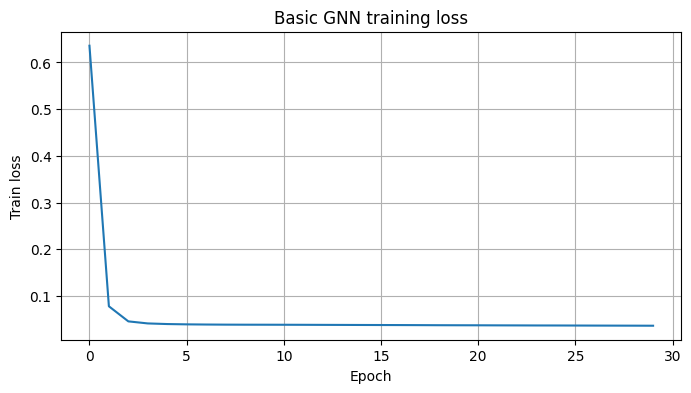

In [92]:
# ============================================================
# 53. PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Basic GNN training loss")
plt.grid(True)
plt.show()

In [93]:
# ============================================================
# 54. CREATE RESULTS DATAFRAME FOR BASIC GNN
# ============================================================

test_datetimes = []
test_zone_codes = []

node_idx_to_zone_code = {
    row["node_idx"]: row["zone_code"]
    for _, row in node_order_check.iterrows()
}

for graph in test_graphs:
    for node_idx in range(graph.x.shape[0]):
        test_datetimes.append(graph.datetime)
        test_zone_codes.append(node_idx_to_zone_code[node_idx])

results_gnn = pd.DataFrame({
    "datetime": test_datetimes,
    "zone_code": test_zone_codes,
    "y_true": y_true_gnn,
    "y_pred": y_pred_gnn,
})

display(results_gnn.head(15))
display(results_gnn.tail(15))

,datetime,zone_code,y_true,y_pred
0,2020-12-01 00:00:00,NO1,12.42,12.510624
1,2020-12-01 00:00:00,NO2,12.42,12.236071
2,2020-12-01 00:00:00,NO3,10.03,11.601958
3,2020-12-01 00:00:00,NO4,10.03,10.057582
4,2020-12-01 00:00:00,NO5,12.42,12.510624
5,2020-12-01 01:00:00,NO1,12.41,11.819122
6,2020-12-01 01:00:00,NO2,12.41,11.610334
7,2020-12-01 01:00:00,NO3,9.96,11.084496
8,2020-12-01 01:00:00,NO4,9.96,9.780967
9,2020-12-01 01:00:00,NO5,12.41,11.819122


,datetime,zone_code,y_true,y_pred
3705,2020-12-31 21:00:00,NO1,24.610001,24.345322
3706,2020-12-31 21:00:00,NO2,24.610001,22.685341
3707,2020-12-31 21:00:00,NO3,24.610001,23.991665
3708,2020-12-31 21:00:00,NO4,17.780001,19.374115
3709,2020-12-31 21:00:00,NO5,24.610001,24.345322
3710,2020-12-31 22:00:00,NO1,24.070000,24.275757
3711,2020-12-31 22:00:00,NO2,24.070000,22.617317
3712,2020-12-31 22:00:00,NO3,23.250000,23.926571
3713,2020-12-31 22:00:00,NO4,17.680000,19.316740
3714,2020-12-31 22:00:00,NO5,24.070000,24.275757


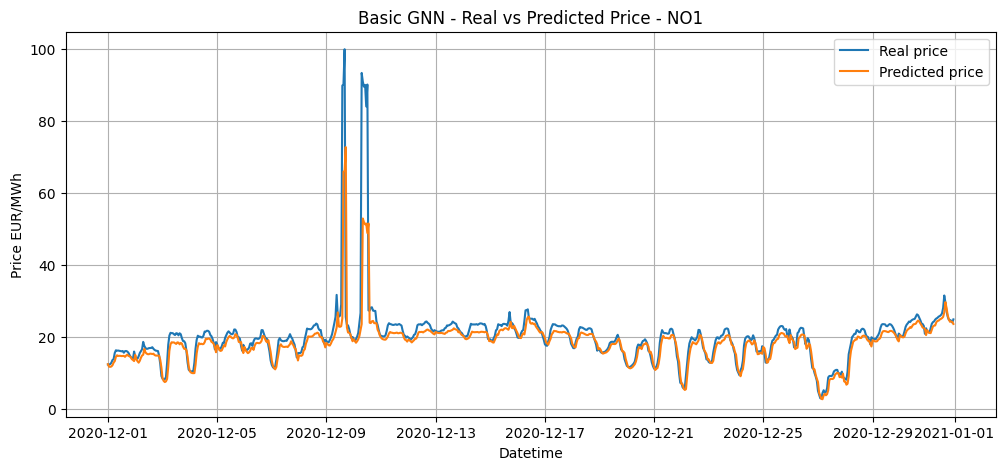

In [94]:
# ============================================================
# 55. PLOT BASIC GNN PREDICTIONS FOR ONE ZONE
# ============================================================

zone_to_plot = "NO1"

plot_df = results_gnn[results_gnn["zone_code"] == zone_to_plot].copy()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["datetime"], plot_df["y_true"], label="Real price")
plt.plot(plot_df["datetime"], plot_df["y_pred"], label="Predicted price")

plt.xlabel("Datetime")
plt.ylabel("Price EUR/MWh")
plt.title(f"Basic GNN - Real vs Predicted Price - {zone_to_plot}")
plt.legend()
plt.grid(True)
plt.show()

In [95]:
# ============================================================
# 56. METRICS BY ZONE
# ============================================================

zone_metrics = []

for zone_code in sorted(results_gnn["zone_code"].unique()):
    zone_df = results_gnn[results_gnn["zone_code"] == zone_code]

    mae = mean_absolute_error(zone_df["y_true"], zone_df["y_pred"])
    rmse = mean_squared_error(zone_df["y_true"], zone_df["y_pred"]) ** 0.5
    r2 = r2_score(zone_df["y_true"], zone_df["y_pred"])

    zone_metrics.append({
        "zone_code": zone_code,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

zone_metrics_df = pd.DataFrame(zone_metrics)

display(zone_metrics_df)

,zone_code,MAE,RMSE,R2
0,NO1,2.019253,5.548314,0.625182
1,NO2,2.720619,5.860171,0.581785
2,NO3,3.284966,4.633989,-0.786637
3,NO4,0.927758,1.518850,0.572441
4,NO5,1.837081,4.314813,0.569569


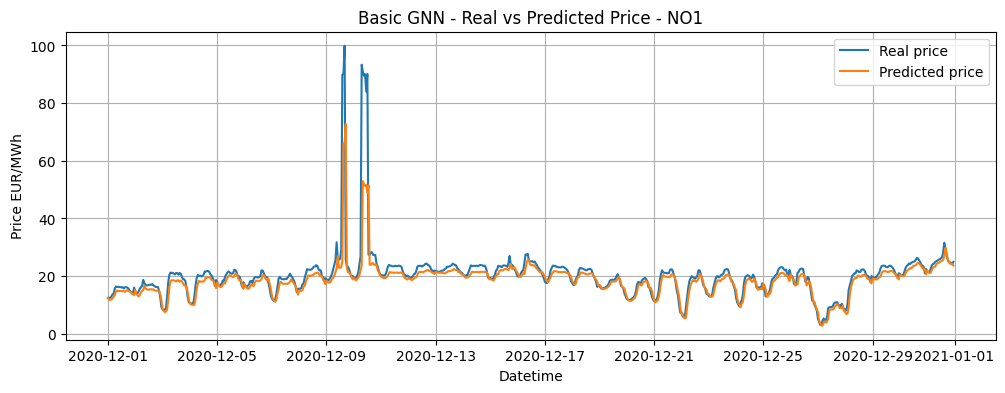

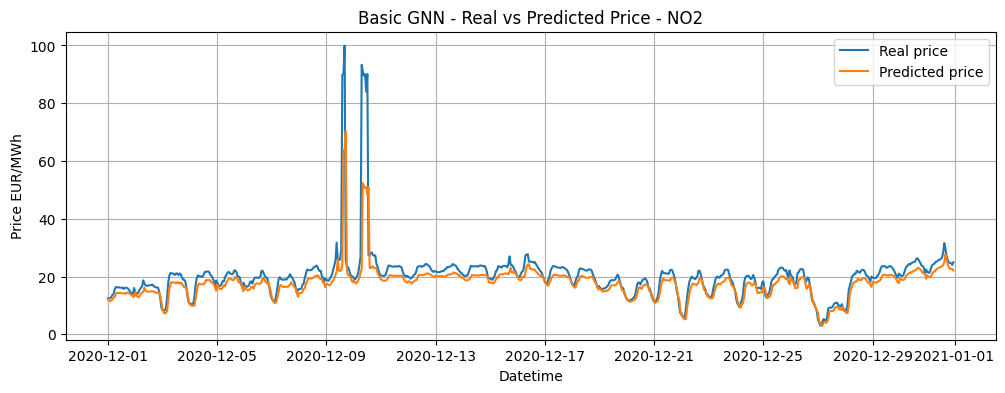

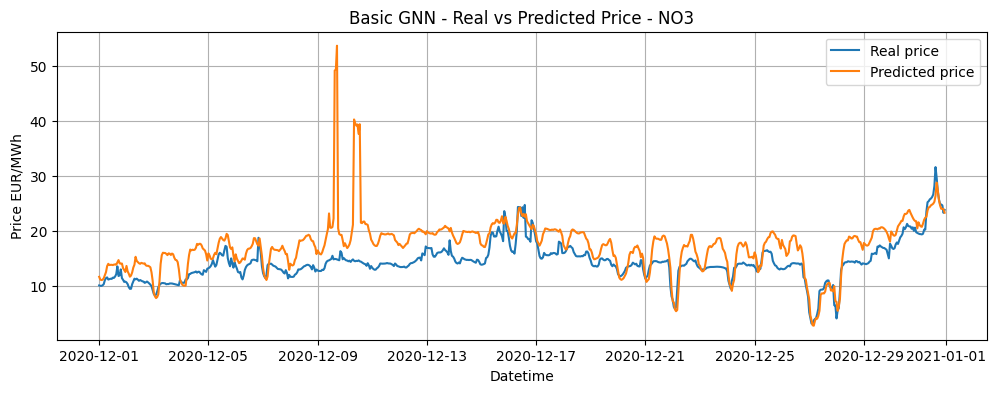

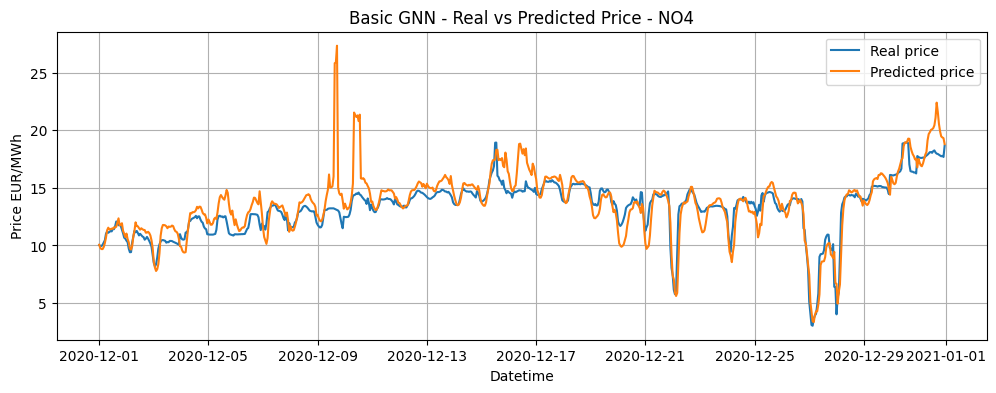

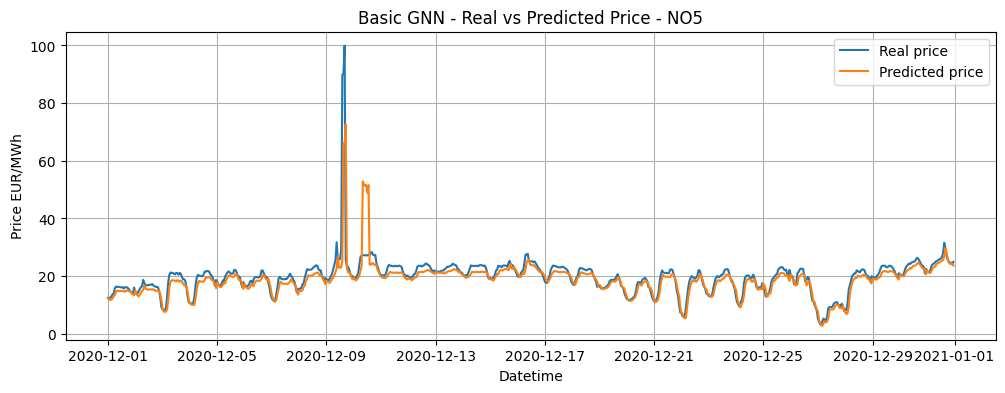

In [96]:
# ============================================================
# 57. PLOT BASIC GNN PREDICTIONS FOR ALL ZONES
# ============================================================

for zone_to_plot in sorted(results_gnn["zone_code"].unique()):
    plot_df = results_gnn[results_gnn["zone_code"] == zone_to_plot].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["datetime"], plot_df["y_true"], label="Real price")
    plt.plot(plot_df["datetime"], plot_df["y_pred"], label="Predicted price")

    plt.xlabel("Datetime")
    plt.ylabel("Price EUR/MWh")
    plt.title(f"Basic GNN - Real vs Predicted Price - {zone_to_plot}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [97]:
# ============================================================
# 58. ADD LAG FEATURES TO NODE DATA
# ============================================================

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

lags = [1, 2, 24]

for lag in lags:
    node_df[f"price_lag_{lag}"] = (
        node_df.groupby("zone_id")["price_value"]
        .shift(lag)
    )

display(node_df.head(30))

print("Missing values after lags:")
display(node_df[
    ["price_lag_1", "price_lag_2", "price_lag_24"]
].isna().sum())

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,target_price_t_plus_1,price_lag_1,price_lag_2,price_lag_24
0,12,2020-01-01,0,31.82,4176.9,1802.2,2020-01-01 00:00:00,31.77,NaN,NaN,NaN
5,12,2020-01-01,1,31.77,4091.8,1819.6,2020-01-01 01:00:00,31.57,31.82,NaN,NaN
10,12,2020-01-01,2,31.57,4021.3,1826.2,2020-01-01 02:00:00,31.28,31.77,31.82,NaN
15,12,2020-01-01,3,31.28,3975.7,1836.8,2020-01-01 03:00:00,30.72,31.57,31.77,NaN
20,12,2020-01-01,4,30.72,3993.6,1841.5,2020-01-01 04:00:00,30.27,31.28,31.57,NaN
25,12,2020-01-01,5,30.27,4041.5,1798.0,2020-01-01 05:00:00,30.17,30.72,31.28,NaN
30,12,2020-01-01,6,30.17,4176.0,1762.8,2020-01-01 06:00:00,30.14,30.27,30.72,NaN
35,12,2020-01-01,7,30.14,4316.6,1750.4,2020-01-01 07:00:00,30.49,30.17,30.27,NaN
40,12,2020-01-01,8,30.49,4639.3,1970.5,2020-01-01 08:00:00,30.59,30.14,30.17,NaN
45,12,2020-01-01,9,30.59,4766.5,1943.4,2020-01-01 09:00:00,30.27,30.49,30.14,NaN


Missing values after lags:


price_lag_1       5
price_lag_2      10
price_lag_24    120
dtype: int64

In [98]:
# ============================================================
# 59. UPDATE NODE FEATURE COLUMNS WITH LAGS
# ============================================================

node_feature_columns = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
    "price_lag_1",
    "price_lag_2",
    "price_lag_24",
]

print("Node feature columns:")
print(node_feature_columns)

Node feature columns:
['price_value', 'buy_volume_value', 'sell_volume_value', 'price_lag_1', 'price_lag_2', 'price_lag_24']


In [99]:
# ============================================================
# 60. FUNCTION TO BUILD ONE GRAPH WITH NODE LAGS
# ============================================================

def build_graph_for_datetime(datetime_value):
    """
    Builds one graph snapshot for a specific datetime.

    Returns a dictionary with:
    - datetime
    - x
    - edge_index
    - edge_attr
    - y
    """

    # -------------------------
    # Node snapshot
    # -------------------------

    node_snapshot = (
        node_df[node_df["datetime"] == datetime_value]
        .copy()
        .sort_values("zone_id")
    )

    # Check that all selected zones are present
    if len(node_snapshot) != len(selected_zone_ids):
        return None

    x = node_snapshot[node_feature_columns].to_numpy(dtype=np.float32)
    y = node_snapshot["target_price_t_plus_1"].to_numpy(dtype=np.float32)

    # Skip graph if node features or target contain NaNs
    if np.isnan(x).any():
        return None

    if np.isnan(y).any():
        return None

    # -------------------------
    # Edge snapshot
    # -------------------------

    edge_snapshot = (
        flows_no[flows_no["datetime"] == datetime_value]
        .copy()
    )

    edge_snapshot = unique_edges.merge(
        edge_snapshot,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    edge_attr = edge_snapshot[edge_feature_columns].to_numpy(dtype=np.float32)

    if np.isnan(edge_attr).any():
        return None

    graph = {
        "datetime": datetime_value,
        "x": x,
        "edge_index": edge_index,
        "edge_attr": edge_attr,
        "y": y,
    }

    return graph

In [100]:
# ============================================================
# 61. REBUILD GRAPH DATASET WITH LAGS
# ============================================================

graphs_lag = []

for datetime_value in common_datetimes:
    graph = build_graph_for_datetime(datetime_value)

    if graph is not None:
        graphs_lag.append(graph)

print("Common datetimes:", len(common_datetimes))
print("Graphs created with lags:", len(graphs_lag))
print("Graphs skipped:", len(common_datetimes) - len(graphs_lag))

print("First graph datetime:", graphs_lag[0]["datetime"])
print("Last graph datetime:", graphs_lag[-1]["datetime"])

print("x shape:", graphs_lag[0]["x"].shape)
print("edge_index shape:", graphs_lag[0]["edge_index"].shape)
print("edge_attr shape:", graphs_lag[0]["edge_attr"].shape)
print("y shape:", graphs_lag[0]["y"].shape)

Common datetimes: 8783
Graphs created with lags: 8758
Graphs skipped: 25
First graph datetime: 2020-01-02 00:00:00
Last graph datetime: 2020-12-31 23:00:00
x shape: (5, 6)
edge_index shape: (2, 12)
edge_attr shape: (12, 1)
y shape: (5,)


In [101]:
# ============================================================
# 62. CONVERT LAG GRAPH DATASET TO PYTORCH GEOMETRIC
# ============================================================

pyg_graphs_lag = []

for graph in graphs_lag:
    data = Data(
        x=torch.tensor(graph["x"], dtype=torch.float),
        edge_index=torch.tensor(graph["edge_index"], dtype=torch.long),
        edge_attr=torch.tensor(graph["edge_attr"], dtype=torch.float),
        y=torch.tensor(graph["y"], dtype=torch.float)
    )
    
    data.datetime = graph["datetime"]
    pyg_graphs_lag.append(data)

print("Number of PyG lag graphs:", len(pyg_graphs_lag))
print("First graph:", pyg_graphs_lag[0])
print("Last graph:", pyg_graphs_lag[-1])

Number of PyG lag graphs: 8758
First graph: Data(x=[5, 6], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-01-02 00:00:00)
Last graph: Data(x=[5, 6], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-12-31 23:00:00)


In [102]:
# ============================================================
# 63. TEMPORAL TRAIN / TEST SPLIT WITH LAGS
# ============================================================

split_datetime = pd.Timestamp("2020-12-01 00:00:00")

train_graphs_lag = [
    graph for graph in pyg_graphs_lag
    if graph.datetime < split_datetime
]

test_graphs_lag = [
    graph for graph in pyg_graphs_lag
    if graph.datetime >= split_datetime
]

print("Train graphs with lags:", len(train_graphs_lag))
print("Test graphs with lags:", len(test_graphs_lag))

print("Train period:")
print(train_graphs_lag[0].datetime, "->", train_graphs_lag[-1].datetime)

print("Test period:")
print(test_graphs_lag[0].datetime, "->", test_graphs_lag[-1].datetime)

Train graphs with lags: 8014
Test graphs with lags: 744
Train period:
2020-01-02 00:00:00 -> 2020-11-30 23:00:00
Test period:
2020-12-01 00:00:00 -> 2020-12-31 23:00:00


In [103]:
# ============================================================
# 64. NORMALIZE LAG GRAPH DATASET
# ============================================================

train_x_all_lag = torch.cat([g.x for g in train_graphs_lag], dim=0)
train_y_all_lag = torch.cat([g.y for g in train_graphs_lag], dim=0)

x_mean_lag = train_x_all_lag.mean(dim=0)
x_std_lag = train_x_all_lag.std(dim=0)
x_std_lag[x_std_lag == 0] = 1.0

y_mean_lag = train_y_all_lag.mean()
y_std_lag = train_y_all_lag.std()

if y_std_lag == 0:
    y_std_lag = torch.tensor(1.0)

print("x_mean_lag:", x_mean_lag)
print("x_std_lag:", x_std_lag)
print("y_mean_lag:", y_mean_lag)
print("y_std_lag:", y_std_lag)

x_mean_lag: tensor([   8.3874, 2670.4575, 3270.2615,    8.3892,    8.3908,    8.4364])
x_std_lag: tensor([   7.0728, 1080.3927, 1490.5031,    7.0763,    7.0799,    7.1640])
y_mean_lag: tensor(8.3861)
y_std_lag: tensor(7.0702)


In [104]:
# ============================================================
# 65. CREATE NORMALIZED LAG GRAPH DATASETS
# ============================================================

train_graphs_lag_norm = [
    normalize_graph(g, x_mean_lag, x_std_lag, y_mean_lag, y_std_lag)
    for g in train_graphs_lag
]

test_graphs_lag_norm = [
    normalize_graph(g, x_mean_lag, x_std_lag, y_mean_lag, y_std_lag)
    for g in test_graphs_lag
]

print("Normalized train graphs with lags:", len(train_graphs_lag_norm))
print("Normalized test graphs with lags:", len(test_graphs_lag_norm))

print(train_graphs_lag_norm[0])

Normalized train graphs with lags: 8014
Normalized test graphs with lags: 744
Data(x=[5, 6], edge_index=[2, 12], edge_attr=[12, 1], y=[5], datetime=2020-01-02 00:00:00)


In [105]:
# ============================================================
# 66. NORMALIZED LAG DATALOADERS
# ============================================================

batch_size = 32

train_loader_lag = DataLoader(
    train_graphs_lag_norm,
    batch_size=batch_size,
    shuffle=False
)

test_loader_lag = DataLoader(
    test_graphs_lag_norm,
    batch_size=batch_size,
    shuffle=False
)

batch_lag = next(iter(train_loader_lag))

print(batch_lag)
print("Batch x:", batch_lag.x.shape)
print("Batch edge_index:", batch_lag.edge_index.shape)
print("Batch edge_attr:", batch_lag.edge_attr.shape)
print("Batch y:", batch_lag.y.shape)

DataBatch(x=[160, 6], edge_index=[2, 384], edge_attr=[384, 1], y=[160], datetime=[32], batch=[160], ptr=[33])
Batch x: torch.Size([160, 6])
Batch edge_index: torch.Size([2, 384])
Batch edge_attr: torch.Size([384, 1])
Batch y: torch.Size([160])


In [106]:
# ============================================================
# 67. DEFINE BASIC GNN MODEL WITH LAG FEATURES
# ============================================================

in_channels_lag = train_graphs_lag_norm[0].x.shape[1]
hidden_channels = 32

model_lag = BasicGNN(
    in_channels=in_channels_lag,
    hidden_channels=hidden_channels
)

model_lag = model_lag.to(device)

optimizer_lag = torch.optim.Adam(
    model_lag.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

print(model_lag)

BasicGNN(
  (conv1): GCNConv(6, 32)
  (conv2): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=1, bias=True)
)


In [107]:
# ============================================================
# 68. TRAIN BASIC GNN WITH LAGS
# ============================================================

num_epochs = 30

train_losses_lag = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(
        model=model_lag,
        loader=train_loader_lag,
        optimizer=optimizer_lag,
        loss_fn=loss_fn,
        device=device
    )

    train_losses_lag.append(train_loss)

    if epoch == 1 or epoch % 5 == 0:
        test_mae, test_rmse, test_r2, _, _ = evaluate_model(
            model=model_lag,
            loader=test_loader_lag,
            device=device,
            y_mean=y_mean_lag,
            y_std=y_std_lag
        )

        print(
            f"Epoch {epoch:03d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test MAE: {test_mae:.4f} | "
            f"Test RMSE: {test_rmse:.4f} | "
            f"Test R2: {test_r2:.4f}"
        )

Epoch 001 | Train loss: 0.5076 | Test MAE: 2.9296 | Test RMSE: 5.4958 | Test R2: 0.4463
Epoch 005 | Train loss: 0.0441 | Test MAE: 2.2292 | Test RMSE: 4.8983 | Test R2: 0.5601
Epoch 010 | Train loss: 0.0380 | Test MAE: 2.1335 | Test RMSE: 4.6381 | Test R2: 0.6056
Epoch 015 | Train loss: 0.0361 | Test MAE: 2.0292 | Test RMSE: 4.5886 | Test R2: 0.6140
Epoch 020 | Train loss: 0.0352 | Test MAE: 1.9943 | Test RMSE: 4.6067 | Test R2: 0.6109
Epoch 025 | Train loss: 0.0346 | Test MAE: 1.9757 | Test RMSE: 4.5998 | Test R2: 0.6121
Epoch 030 | Train loss: 0.0340 | Test MAE: 1.9174 | Test RMSE: 4.5532 | Test R2: 0.6199


In [108]:
# ============================================================
# 69. FINAL TEST METRICS - BASIC GNN WITH LAGS
# ============================================================

test_mae_lag, test_rmse_lag, test_r2_lag, y_true_gnn_lag, y_pred_gnn_lag = evaluate_model(
    model=model_lag,
    loader=test_loader_lag,
    device=device,
    y_mean=y_mean_lag,
    y_std=y_std_lag
)

print("FINAL BASIC GNN WITH LAGS RESULTS")
print("---------------------------------")
print(f"MAE:  {test_mae_lag:.4f}")
print(f"RMSE: {test_rmse_lag:.4f}")
print(f"R2:   {test_r2_lag:.4f}")

FINAL BASIC GNN WITH LAGS RESULTS
---------------------------------
MAE:  1.9174
RMSE: 4.5532
R2:   0.6199


In [109]:
# ============================================================
# 70. CREATE RESULTS DATAFRAME FOR BASIC GNN WITH LAGS
# ============================================================

test_datetimes_lag = []
test_zone_codes_lag = []

for graph in test_graphs_lag:
    for node_idx in range(graph.x.shape[0]):
        test_datetimes_lag.append(graph.datetime)
        test_zone_codes_lag.append(node_idx_to_zone_code[node_idx])

results_gnn_lag = pd.DataFrame({
    "datetime": test_datetimes_lag,
    "zone_code": test_zone_codes_lag,
    "y_true": y_true_gnn_lag,
    "y_pred": y_pred_gnn_lag,
})

display(results_gnn_lag.head(15))
display(results_gnn_lag.tail(15))

,datetime,zone_code,y_true,y_pred
0,2020-12-01 00:00:00,NO1,12.42,13.309275
1,2020-12-01 00:00:00,NO2,12.42,13.231665
2,2020-12-01 00:00:00,NO3,10.03,11.788074
3,2020-12-01 00:00:00,NO4,10.03,10.385695
4,2020-12-01 00:00:00,NO5,12.42,13.309275
5,2020-12-01 01:00:00,NO1,12.41,12.272655
6,2020-12-01 01:00:00,NO2,12.41,12.262668
7,2020-12-01 01:00:00,NO3,9.96,11.266394
8,2020-12-01 01:00:00,NO4,9.96,10.109674
9,2020-12-01 01:00:00,NO5,12.41,12.272655


,datetime,zone_code,y_true,y_pred
3705,2020-12-31 21:00:00,NO1,24.610001,25.928015
3706,2020-12-31 21:00:00,NO2,24.610001,24.215786
3707,2020-12-31 21:00:00,NO3,24.610001,24.992657
3708,2020-12-31 21:00:00,NO4,17.780001,20.240788
3709,2020-12-31 21:00:00,NO5,24.610001,25.928015
3710,2020-12-31 22:00:00,NO1,24.070000,25.820456
3711,2020-12-31 22:00:00,NO2,24.070000,24.100983
3712,2020-12-31 22:00:00,NO3,23.250000,24.894131
3713,2020-12-31 22:00:00,NO4,17.680000,20.274910
3714,2020-12-31 22:00:00,NO5,24.070000,25.820456


In [110]:
# ============================================================
# 71. METRICS BY ZONE - BASIC GNN WITH LAGS
# ============================================================

zone_metrics_lag = []

for zone_code in sorted(results_gnn_lag["zone_code"].unique()):
    zone_df = results_gnn_lag[results_gnn_lag["zone_code"] == zone_code]

    mae = mean_absolute_error(zone_df["y_true"], zone_df["y_pred"])
    rmse = mean_squared_error(zone_df["y_true"], zone_df["y_pred"]) ** 0.5
    r2 = r2_score(zone_df["y_true"], zone_df["y_pred"])

    zone_metrics_lag.append({
        "zone_code": zone_code,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

zone_metrics_lag_df = pd.DataFrame(zone_metrics_lag)

display(zone_metrics_lag_df)

,zone_code,MAE,RMSE,R2
0,NO1,1.438395,5.161332,0.675644
1,NO2,1.759097,5.294994,0.658563
2,NO3,3.814147,5.278571,-1.318243
3,NO4,1.270455,1.808755,0.393646
4,NO5,1.304991,4.224305,0.587437


In [111]:
# ============================================================
# 72. COMPARE BASIC GNN VS BASIC GNN WITH LAGS BY ZONE
# ============================================================

comparison_zone_metrics = zone_metrics_df.merge(
    zone_metrics_lag_df,
    on="zone_code",
    suffixes=("_basic", "_lag")
)

comparison_zone_metrics["MAE_improvement_%"] = (
    (comparison_zone_metrics["MAE_basic"] - comparison_zone_metrics["MAE_lag"])
    / comparison_zone_metrics["MAE_basic"]
    * 100
)

comparison_zone_metrics["RMSE_improvement_%"] = (
    (comparison_zone_metrics["RMSE_basic"] - comparison_zone_metrics["RMSE_lag"])
    / comparison_zone_metrics["RMSE_basic"]
    * 100
)

comparison_zone_metrics["R2_change"] = (
    comparison_zone_metrics["R2_lag"] - comparison_zone_metrics["R2_basic"]
)

display(comparison_zone_metrics)

,zone_code,MAE_basic,RMSE_basic,R2_basic,MAE_lag,RMSE_lag,R2_lag,MAE_improvement_%,RMSE_improvement_%,R2_change
0,NO1,2.019253,5.548314,0.625182,1.438395,5.161332,0.675644,28.765974,6.974776,0.050462
1,NO2,2.720619,5.860171,0.581785,1.759097,5.294994,0.658563,35.342016,9.644365,0.076778
2,NO3,3.284966,4.633989,-0.786637,3.814147,5.278571,-1.318243,-16.109178,-13.909855,-0.531606
3,NO4,0.927758,1.518850,0.572441,1.270455,1.808755,0.393646,-36.938165,-19.087107,-0.178794
4,NO5,1.837081,4.314813,0.569569,1.304991,4.224305,0.587437,28.963848,2.097614,0.017868
